- #### Libs & Functions 

In [1]:
# import packages
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, confusion_matrix, classification_report


- ####  Global Parameters

- ####  Read Data

In [2]:
path = "C:/Users/clamo/Documents/Doutorado/HC/hc_models/features/"

In [3]:
internacao = pd.read_parquet(path + "features_internacao.parquet").reset_index(drop=True)
targets = pd.read_parquet(path + "target_internacao.parquet").reset_index(drop=True)
evolucoes = pd.read_parquet(path + "embbeding_evolucao.parquet").reset_index(drop=True)
pacientes = pd.read_parquet(path + "pacientes.parquet").reset_index(drop=True)
exames = pd.read_parquet(path + "features_exames.parquet").reset_index(drop=True)
consultas = pd.read_parquet(path + "features_consultas.parquet").reset_index(drop=True)

In [4]:

internacao["prontuario"] = internacao["prontuario"].astype("Int64").astype(str)
#targets["prontuario"] = targets["prontuario"].astype("Int64").astype(str)
#evolucoes["prontuario"] = evolucoes["prontuario"].astype("Int64").astype(str)
pacientes["prontuario"] = pacientes["prontuario"].astype("Int64").astype(str)
exames["prontuario"] = exames["prontuario"].astype("Int64").astype(str)
consultas["prontuario"] = consultas["prontuario"].astype("Int64").astype(str)

In [5]:
# Converte targets para datetime
targets["date_ref"] = pd.to_datetime(targets["date_ref"], errors="coerce").dt.normalize()

# Garante que os outros também estejam normalizados (sem horas)
internacao["date_ref"] = pd.to_datetime(internacao["date_ref"], errors="coerce").dt.normalize()
#evolucoes["date_ref"] = pd.to_datetime(evolucoes["date_ref"], errors="coerce").dt.normalize()

In [6]:
#evolucoes.sort_values(["prontuario", "date_ref"])

In [7]:
data = targets.merge(pacientes, on=["prontuario"])
data.shape

(36429, 15)

In [8]:
data= data.merge(internacao, on=["prontuario", "date_ref"],  how='left')
data.shape

(36429, 63)

In [9]:
data= data.merge(exames, on=["prontuario", "date_ref"],  how='left')
data.shape

(36429, 83)

In [10]:
data= data.merge(consultas, on=["prontuario", "date_ref"],  how='left')
data.shape

(36429, 87)

In [11]:
# Converte targets para datetime
#targets["date_ref"] = pd.to_datetime(targets["date_ref"], errors="coerce").dt.normalize()

# Garante que os outros também estejam normalizados (sem horas)
#internacao["date_ref"] = pd.to_datetime(internacao["date_ref"], errors="coerce").dt.normalize()
#evolucoes["date_ref"] = pd.to_datetime(evolucoes["date_ref"], errors="coerce").dt.normalize()

In [12]:
targets[["mais_de_7_dias"]].groupby("mais_de_7_dias").size()

mais_de_7_dias
0    28647
1     7782
dtype: int64

In [13]:
targets[["mais_de_15_dias"]].groupby("mais_de_15_dias").size()

mais_de_15_dias
0    32965
1     3464
dtype: int64

In [14]:
# pd show all rows
pd.set_option('display.max_rows', None)

In [15]:
# total rows
total_rows = len(data)

# count nulls and percentages
null_counts = data.isnull().sum()
null_percent = (null_counts / total_rows) * 100

# combine into one DataFrame
null_stats = pd.DataFrame({
    "null_count": null_counts,
    "null_percent": null_percent
}).reset_index()

print(null_stats)

                                     index  null_count  null_percent
0                               prontuario           0      0.000000
1                                 date_ref           0      0.000000
2                           dias_internado           0      0.000000
3                           mais_de_4_dias           0      0.000000
4                           mais_de_7_dias           0      0.000000
5                          mais_de_15_dias           0      0.000000
6                                    idade           0      0.000000
7                               cor_branca           0      0.000000
8                             cor_indigena           0      0.000000
9                              cor_amarela           0      0.000000
10                               cor_preta           0      0.000000
11                              cor_marrom           0      0.000000
12                              cor_outras           0      0.000000
13                           sexo_

<h3> Split data <h3>

In [16]:
# remove agosto de 2021 pra tras por conta da build dos dados
#data = data[data["date_ref"] >= "2023-07-01"]

In [17]:
# Calculando a porcentagem de nulos para cada coluna de `data`
null_percent = data.isnull().mean() * 100

# Identificando as colunas com mais de 90% de nulos
cols_to_drop = null_percent[null_percent > 95].index

# Removendo essas colunas do DataFrame `data`
data = data.drop(columns=cols_to_drop)

# Exibindo as colunas removidas e o novo DataFrame
print("Colunas removidas:", cols_to_drop)

Colunas removidas: Index(['a_qtd_media_dias_internado', 'b_qtd_media_dias_internado',
       'd_qtd_media_dias_internado', 'e_qtd_media_dias_internado',
       'f_qtd_media_dias_internado', 'g_qtd_media_dias_internado',
       'h_qtd_media_dias_internado', 'i_qtd_media_dias_internado',
       'j_qtd_media_dias_internado', 'k_qtd_media_dias_internado',
       'l_qtd_media_dias_internado', 'm_qtd_media_dias_internado',
       'o_qtd_media_dias_internado', 'outros_qtd_media_dias_internado',
       'p_qtd_media_dias_internado', 'q_qtd_media_dias_internado',
       'r_qtd_media_dias_internado', 't_qtd_media_dias_internado',
       'y_qtd_media_dias_internado', 'z_qtd_media_dias_internado',
       'a_valor_max_date', 'b_valor_max_date', 'd_valor_max_date',
       'e_valor_max_date', 'f_valor_max_date', 'g_valor_max_date',
       'h_valor_max_date', 'i_valor_max_date', 'j_valor_max_date',
       'k_valor_max_date', 'l_valor_max_date', 'm_valor_max_date',
       'o_valor_max_date', 'outros_val

In [18]:
#list(data.columns)

In [19]:
target_column = 'mais_de_15_dias'

In [20]:
nowanted_cols = ['prontuario', 'date_ref', 'dias_internado', 'mais_de_4_dias', 'mais_de_7_dias', 'mais_de_15_dias']

feature_columns = [item for item in list(data.columns) if item not in nowanted_cols]


In [21]:
# split for time evaluation
target_time = data[data["date_ref"] >= "2025-06-01"]['mais_de_7_dias']
target = data[data["date_ref"] < "2025-06-01"]['mais_de_7_dias']

#
features_time = data[data["date_ref"] >= "2025-06-01"][feature_columns]
features = data[data["date_ref"] < "2025-06-01"][feature_columns]

In [22]:

# 1. Remove colunas que não são numéricas ou booleanas
#train = train.select_dtypes(include=["number", "bool"]).copy()

# 2. Substitui infinitos por NaN
#train = train.replace([np.inf, -np.inf], np.nan)

# --- data ---
# df = pd.read_csv("data.csv")
#target = "target_180_empretec"
#X = train.drop(columns=[target] + ([ 'date_ref'] if 'date_ref' in train.columns else [])).copy()
#y = train[target].astype(int)

#X = X.select_dtypes(include=["number", "bool"]).copy()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.15, random_state=42)

In [24]:
# --- model ---
clf = LGBMClassifier(random_state=42)
clf.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6036, number of negative: 22125
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 28161, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.214339 -> initscore=-1.298967
[LightGBM] [Info] Start training from score -1.298967


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### eval o time

AUROC: 0.8315


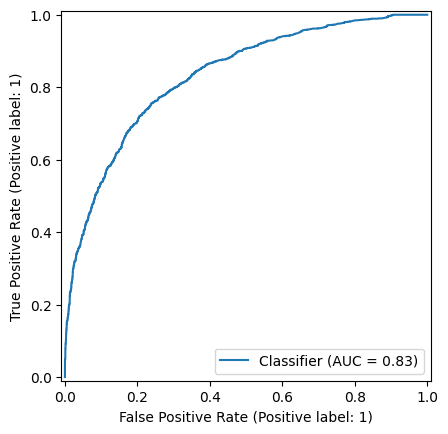

In [25]:

# --- AUROC ---
proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"AUROC: {auc:.4f}")

# --- ROC curve (optional) ---
RocCurveDisplay.from_predictions(y_test, proba)

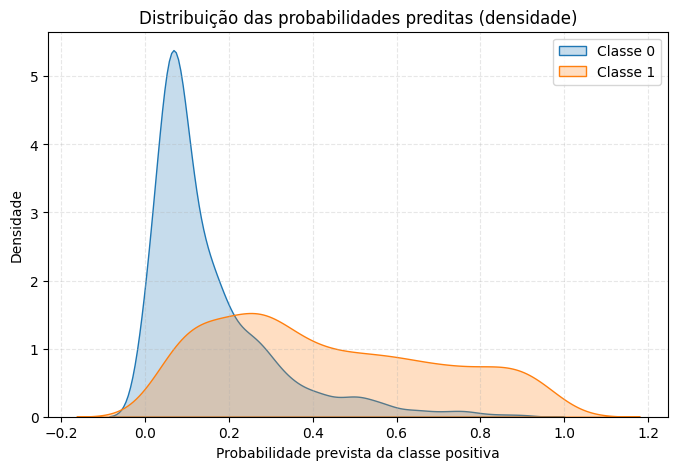

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Gráfico de densidade dos scores preditos ---
plt.figure(figsize=(8, 5))
sns.kdeplot(proba[y_test == 0], label="Classe 0", fill=True)
sns.kdeplot(proba[y_test == 1], label="Classe 1", fill=True)
plt.title("Distribuição das probabilidades preditas (densidade)")
plt.xlabel("Probabilidade prevista da classe positiva")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


AUROC:   0.8315
Accuracy:0.8270
Precision:0.7030
Recall:  0.3802
F1-score:0.4935

Confusion Matrix:
[[3691  177]
 [ 683  419]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8439    0.9542    0.8957      3868
           1     0.7030    0.3802    0.4935      1102

    accuracy                         0.8270      4970
   macro avg     0.7734    0.6672    0.6946      4970
weighted avg     0.8126    0.8270    0.8065      4970



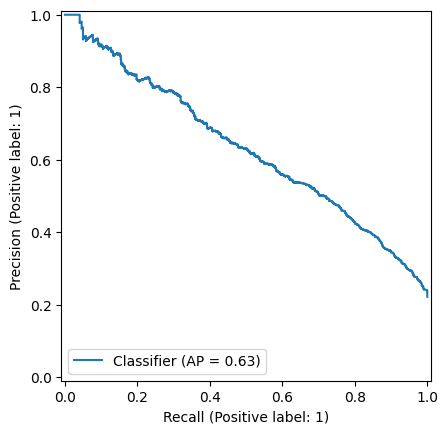

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay
)

# --- Predictions ---
preds = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

# --- Metrics ---
auc = roc_auc_score(y_test, proba)
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, zero_division=0)
rec = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print(f"AUROC:   {auc:.4f}")
print(f"Accuracy:{acc:.4f}")
print(f"Precision:{prec:.4f}")
print(f"Recall:  {rec:.4f}")
print(f"F1-score:{f1:.4f}")

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

# --- Full Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, preds, digits=4))

# --- Precision-Recall Curve (useful for imbalance) ---
PrecisionRecallDisplay.from_predictions(y_test, proba)


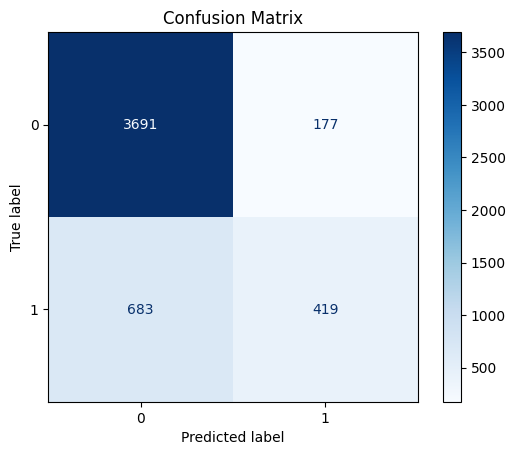

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, preds)

# Create a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")
plt.show()

#### eval out of time

AUROC: 0.8397


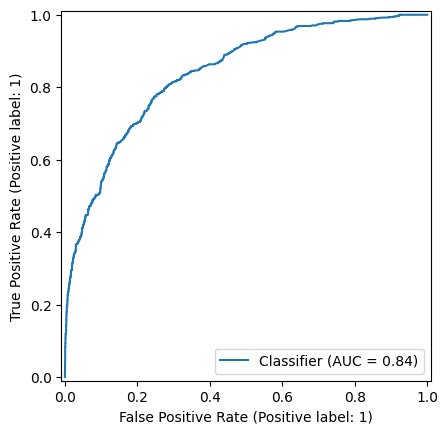

In [29]:

# --- AUROC ---
proba = clf.predict_proba(features_time)[:, 1]
auc = roc_auc_score(target_time, proba)
print(f"AUROC: {auc:.4f}")

# --- ROC curve (optional) ---
RocCurveDisplay.from_predictions(target_time, proba)

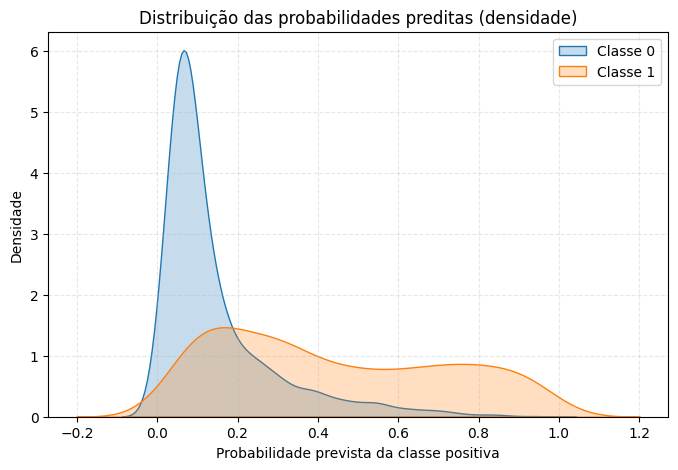

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Gráfico de densidade dos scores preditos ---
plt.figure(figsize=(8, 5))
sns.kdeplot(proba[target_time == 0], label="Classe 0", fill=True)
sns.kdeplot(proba[target_time == 1], label="Classe 1", fill=True)
plt.title("Distribuição das probabilidades preditas (densidade)")
plt.xlabel("Probabilidade prevista da classe positiva")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

AUROC:   0.8397
Accuracy:0.8451
Precision:0.6822
Recall:  0.3866
F1-score:0.4936

Confusion Matrix:
[[2538  116]
 [ 395  249]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8653    0.9563    0.9085      2654
           1     0.6822    0.3866    0.4936       644

    accuracy                         0.8451      3298
   macro avg     0.7738    0.6715    0.7010      3298
weighted avg     0.8296    0.8451    0.8275      3298



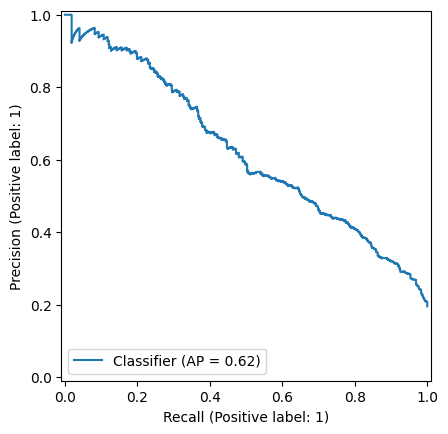

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay
)

# --- Predictions ---
preds = clf.predict(features_time)
proba = clf.predict_proba(features_time)[:, 1]

# --- Metrics ---
auc = roc_auc_score(target_time, proba)
acc = accuracy_score(target_time, preds)
prec = precision_score(target_time, preds, zero_division=0)
rec = recall_score(target_time, preds)
f1 = f1_score(target_time, preds)

print(f"AUROC:   {auc:.4f}")
print(f"Accuracy:{acc:.4f}")
print(f"Precision:{prec:.4f}")
print(f"Recall:  {rec:.4f}")
print(f"F1-score:{f1:.4f}")

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
print(confusion_matrix(target_time, preds))

# --- Full Classification Report ---
print("\nClassification Report:")
print(classification_report(target_time, preds, digits=4))

# --- Precision-Recall Curve (useful for imbalance) ---
PrecisionRecallDisplay.from_predictions(target_time, proba)

In [32]:
#false_negatives = X_test[(preds == 0) & (y_test == 1)]
#false_negatives

In [33]:

# proba = clf.predict_proba(X_test)[:, 1]
# y_test = target_time

# --- 1) Threshold que maximiza F1 ---
prec, rec, thr = precision_recall_curve(target_time, proba)
# obs: len(thr) = len(prec) - 1 = len(rec) - 1
f1_vals = (2 * prec[1:] * rec[1:]) / (prec[1:] + rec[1:] + 1e-12)
i_best = np.argmax(f1_vals)
best_thr = thr[i_best]

preds_best = (proba >= best_thr).astype(int)
print(f"[F1 Máximo] threshold = {best_thr:.4f}")
print(f"Precision={precision_score(target_time, preds_best, zero_division=0):.4f} | "
      f"Recall={recall_score(target_time, preds_best):.4f} | "
      f"F1={f1_score(target_time, preds_best):.4f}")
print("Confusion Matrix:\n", confusion_matrix(target_time, preds_best))
print("\nClassification Report:\n", classification_report(target_time, preds_best, digits=4))

# --- 2) Threshold com recall mínimo (ex.: >= 0.70) e melhor F1 entre eles ---
recall_min = 0.70
candidates = np.where(rec[1:] >= recall_min)[0]
if len(candidates) > 0:
    j = candidates[np.argmax(f1_vals[candidates])]
    thr_rec = thr[j]
    preds_rec = (proba >= thr_rec).astype(int)
    print(f"\n[Recall ≥ {recall_min:.2f}] threshold = {thr_rec:.4f}")
    print(f"Precision={precision_score(target_time, preds_rec, zero_division=0):.4f} | "
          f"Recall={recall_score(target_time, preds_rec):.4f} | "
          f"F1={f1_score(target_time, preds_rec):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(target_time, preds_rec))
else:
    print(f"\nNenhum threshold alcança recall ≥ {recall_min:.2f}. "
          "Tente reduzir o limite ou ajustar class_weight/params do modelo.")


[F1 Máximo] threshold = 0.2724
Precision=0.5220 | Recall=0.6444 | F1=0.5768
Confusion Matrix:
 [[2274  380]
 [ 229  415]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9085    0.8568    0.8819      2654
           1     0.5220    0.6444    0.5768       644

    accuracy                         0.8153      3298
   macro avg     0.7153    0.7506    0.7293      3298
weighted avg     0.8330    0.8153    0.8223      3298


[Recall ≥ 0.70] threshold = 0.2208
Precision=0.4640 | Recall=0.7003 | F1=0.5582
Confusion Matrix:
 [[2133  521]
 [ 193  451]]
